In [2]:
import argparse, h5py, numpy as np, pycbc.detector, logging
from numpy.random import uniform, normal
from copy import deepcopy
from collections import defaultdict
from pycbc.waveform import get_fd_waveform
from pycbc.psd import aLIGOZeroDetHighPower
from scipy.interpolate import RectBivariateSpline
from matplotlib import pyplot as plt
import random
plt.style.use("paper.mplstyle")

In [3]:
ifos = ['H1', 'L1']
d = {ifo: pycbc.detector.Detector(ifo) for ifo in ifos}


np.random.seed(5)
size = 1000000


# Use the first detector as a reference. The reference ifo is used 
# to get the correct symmetries when measuring dt, dp and sr for the triggers.
ifo0 = ifos[0]
other_ifos = deepcopy(ifos)
other_ifos.remove(ifo0)
counts = defaultdict(list)

l = 0
nsamples = 0
all_keys = []
while len(all_keys)<=1000:
    nsamples += size
    logging.info('generating %s samples', size)

    # Choose random sky location and polarizations from
    # an isotropic population. Distance is drawn from a 
    # squared power law distribution. D_max is chosen 
    # such that the SNR tail is normlaized to commonly 
    # commonly used values.
    ra = uniform(0, 2 * np.pi, size=size)
    dec = np.arccos(uniform(-1., 1., size=size)) - np.pi/2
    inc = np.arccos(uniform(-1., 1., size=size))
    pol = uniform(0, 2 * np.pi, size=size)
    ic = np.cos(inc)
    ip = 0.5 * (1.0 + ic * ic)
    D_max=0.6 * np.min([1.0,1.0])
    uniform_random = np.random.uniform(0, 1, size=size)
    distance = D_max * (uniform_random)**(1/3) 
    print(D_max)

    # calculate the toa, poa, and amplitude of each sample,
    # including uncertainties in measurements.
    data = {}
    for rs, ifo in zip([1,1], ifos):
        data[ifo] = {}
        fp, fc = d[ifo].antenna_pattern(ra, dec, pol, 0)
        sp, sc = fp * ip, fc * ic
        data[ifo]['amp'] = (sp**2+sc**2)**0.5*rs #Amplitude without uncertainities
        snr_sp = (rs*sp/distance) 
        snr_sc = (rs*sc/distance) 
        data[ifo]['op'] = np.arctan2(snr_sc, snr_sp) #Phase without uncertainties
        fsize = snr_sp.shape
        # Add noise to the SNR measurements
        normal_sp = normal(scale=1, size=fsize)
        normal_sc = normal(scale=1, size=fsize)
        snr_sp += normal_sp
        snr_sc += normal_sc
        data[ifo]['snr'] = (snr_sp**2+snr_sc**2)**0.5
        # Add noise to the phase and time measurements
        # Values obtained from modelling time and phase unc, t_unc given by Fairhurst 2009
        p_unc = 2.2/data[ifo]['snr']
        t_unc = 1/(2*np.pi*30*data[ifo]['snr'])
        rho = 0.86
        # Cholensky Decomposition
        l22_factor = np.sqrt(1.0 - rho**2)
        z_p = normal(size=fsize)
        z_t = normal(size=fsize)
        normal_dp = p_unc * z_p
        normal_dt = (rho * t_unc * z_p) + (t_unc * l22_factor * z_t)
        data[ifo]['p'] = (data[ifo]['op'] + normal_dp) % (2. * np.pi)
        data[ifo]['t'] = d[ifo].time_delay_from_earth_center(ra, dec, 0) + normal_dt
        

    # Organise the data
    bind = []
    keep = None
    for ifo1 in other_ifos:
        dt = (data[ifo0]['t'] - data[ifo1]['t'])
        dp = (data[ifo0]['p'] - data[ifo1]['p']) % (2. * np.pi)
        sr = np.log(data[ifo1]['snr'] / data[ifo0]['snr'])
        dtbin = dt
        dpbin = dp
        srbin = sr
        bind += [dtbin, dpbin, srbin, data['L1']['snr']]
        
            
    # Measure network SNR.
    snrs_sq=np.zeros(len(data[ifo0]['snr']))
    for ifo in ifos:
        snrs_sq += data[ifo]['snr']**2
    net_snr = snrs_sq**0.5
    
    # Applying thresholding, individual detector SNR > 5,
    # network SNR > 9.
    keep = None 
    for ifo in ifos:
        if keep is None:
            keep = (net_snr >= 9) & (data[ifo]['snr']>= 5 )
        else:
            keep = keep & (net_snr >= 9) & (data[ifo]['snr']>= 5 )

    #Calculate and sum the weights for each bin
    # use first ifo as reference for weights
    bind = [a[keep] for a in bind]
    for key in zip(*bind):
        all_keys.append(key)

0.6


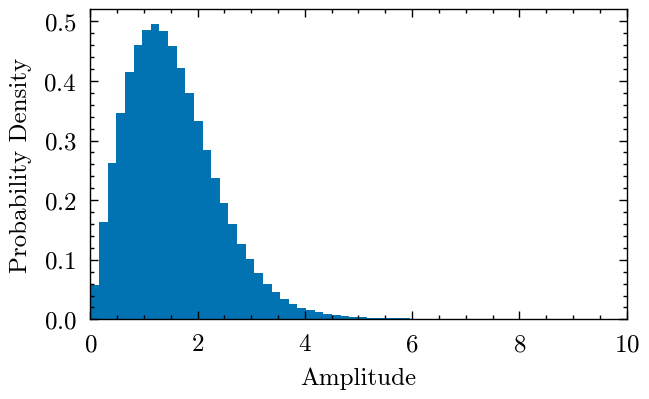

In [6]:
plt.hist(data['L1']['snr'], bins=500, density=True)
plt.xlim(0,10)
plt.ylabel('Probability Density')
plt.xlabel('Amplitude')
plt.savefig("../Plots/L1_Amplitude_Distribution.png")
plt.show()